In [16]:
# CARGA DE DATOS #

import pandas as pd
# test comment
# Ruta al archivo de Excel
archivo_excel = './IIYNT-REQ-BD-003.xlsx' #../

# Número de la fila desde la cual querés empezar (0-indexado)
fila_inicio = 3

# Leer el archivo Excel
init_df = pd.read_excel(archivo_excel)

# Mostrar las primeras filas del DataFrame para confirmar que se leyó bien
init_df.head()

# TRANSFORMACIÓN DE DATOS #

desired_columns = [
    'Temperatura Ambiental (°C)', 
    'Humedad',
    'Temperatura de la muestra (°C)', 
    'pH', 
    'CE\n(µS/cm)', 
    'STD\n(mg/L)',
    'STS\n(mL sed/L)', 
    'OD\n(mg/L)', 
    'Nivel (cm)', 
    'Turbidez (NTU)',
    'Dureza\n(mg CaCO3/L)', 
    'Cloruros\n(mg Cl-/L)'
]
df = init_df.iloc[2:123][desired_columns]
df


,Temperatura Ambiental (°C),Humedad,Temperatura de la muestra (°C),pH,CE\n(µS/cm),STD\n(mg/L),STS\n(mL sed/L),OD\n(mg/L),Nivel (cm),Turbidez (NTU),Dureza\n(mg CaCO3/L),Cloruros\n(mg Cl-/L)
2,16,0.929,18,8.2,1240,610,NaN,5.37,NaN,NaN,NaN,NaN
3,17,0.47,19,8.3,1630,810,1.8,4.3,NaN,NaN,147,156
4,11.9,0.47,13,8.1,1000,490,18,5.3,NaN,41.2,94,78
5,11.9,0.47,13,8.2,1000,490,18,4.67,NaN,38.9,86,82
6,11.9,0.47,13,8.3,1350,670,0.1,7.01,NaN,30.7,200,117
...,...,...,...,...,...,...,...,...,...,...,...,...
118,12.8,0.57,15.3,8,1110,550,18,4.18,25,5.04,316,66
119,12.8,0.57,15.3,8.1,1080,550,18,4.23,25,5.69,316,66
120,12.8,0.57,15.4,8.4,1050,520,44,1.96,70,113,146,82
121,12.8,0.57,15.4,8.4,1070,530,44,1.67,70,133,146,82


In [17]:

#ver los que tienen valores nulos o no asignados

#df.isnull().sum()
df.isna().sum()

#Eliminar las filas que tienen valores nulos o no asignados
#df.dropna(inplace=True) #aca se modifica el Dataframe original con inplace=true

#Si asigno a nueva variable no hace falta inplace=true pero no modifica el Dataframe original
#df_sin_nulos=df.dropna()

#Como opcion puedo llenar los valores nulos con datos adecuados: 
#fillna(method='bfill') (llenar con el valor siguiente de la columna)
#fillna(method='ffill') (llenar con el valor anterior de la columna)
#fillna(0) (llenar con ceros) 

mediaNivel=df['Nivel (cm)'].mean()
df['Nivel (cm)']=df['Nivel (cm)'].fillna(mediaNivel)

mediaSTS=df['STS\n(mL sed/L)'].mean()
df['STS\n(mL sed/L)']=df['STS\n(mL sed/L)'].fillna(mediaSTS)

mediaTurbidez=df['Turbidez (NTU)'].mean()
df['Turbidez (NTU)']=df['Turbidez (NTU)'].fillna(mediaTurbidez)

mediaDureza=df['Dureza\n(mg CaCO3/L)'].mean()
df['Dureza\n(mg CaCO3/L)']=df['Dureza\n(mg CaCO3/L)'].fillna(mediaDureza)

mediaCloruros=df['Cloruros\n(mg Cl-/L)'].mean()
df['Cloruros\n(mg Cl-/L)']=df['Cloruros\n(mg Cl-/L)'].fillna(mediaCloruros)

df_sin_nulos=df.copy()
df_sin_nulos.isna().sum()

#Eliminar las filas que tienen valores nulos o no asignados
df_sin_nulos.dropna(inplace=True) #aca se modifica el Dataframe original con inplace=true
df_sin_nulos.isna().sum()

Temperatura Ambiental (°C)        0
Humedad                           0
Temperatura de la muestra (°C)    0
pH                                0
CE\n(µS/cm)                       0
STD\n(mg/L)                       0
STS\n(mL sed/L)                   0
OD\n(mg/L)                        0
Nivel (cm)                        0
Turbidez (NTU)                    0
Dureza\n(mg CaCO3/L)              0
Cloruros\n(mg Cl-/L)              0
dtype: int64

In [18]:
df_sin_nulos.describe()

,STS\n(mL sed/L),Nivel (cm),Turbidez (NTU),Dureza\n(mg CaCO3/L),Cloruros\n(mg Cl-/L)
count,120.000000,120.000000,120.000000,120.000000,120.000000
mean,68.326496,39.937500,155.879746,172.495798,96.871795
std,109.747232,10.695239,245.077765,54.242666,27.726012
min,0.100000,20.000000,2.680000,86.000000,15.000000
25%,28.000000,30.000000,38.800000,135.000000,74.500000
50%,50.000000,39.937500,79.650000,157.000000,104.000000
75%,70.000000,45.000000,148.500000,204.000000,118.000000
max,650.000000,70.000000,1000.000000,316.000000,156.000000


In [19]:
def min_max_info(dataframe: pd.DataFrame) -> pd.DataFrame:
    name = list()
    minimums = list()
    maximums = list()
    median = list()
    std = list()
    for i, key in enumerate(dataframe.columns):
        name.append(key)
        minimums.append(dataframe[key].min())
        maximums.append(dataframe[key].max())
        median.append(dataframe[key].median())
        std.append(dataframe[key].std())
        
    return pd.DataFrame(
        {
            'name': name,
            'mins': minimums,
            'maxs': maximums,
            'median': median,
            'std': std
        }
    )
min_max_info(df_sin_nulos)

,name,mins,maxs,median,std
0,Temperatura Ambiental (°C),10.40,26.000,14.4000,4.380318
1,Humedad,0.36,0.929,0.5600,0.164879
2,Temperatura de la muestra (°C),12.80,28.100,16.9000,2.915339
3,pH,7.20,8.700,8.2000,0.245005
4,CE\n(µS/cm),200.00,1690.000,1290.0000,253.967054
5,STD\n(mg/L),140.00,840.000,635.0000,125.125119
6,STS\n(mL sed/L),0.10,650.000,50.0000,109.747232
7,OD\n(mg/L),0.00,9.120,3.1500,2.097971
8,Nivel (cm),20.00,70.000,39.9375,10.695239
9,Turbidez (NTU),2.68,1000.000,79.6500,245.077765


In [20]:
def normalize(dataframe: pd.DataFrame, min: float, max: float) -> pd.DataFrame:
    return (dataframe - min) / (max - min)

def denormalize(dataframe: pd.DataFrame, min: float, max: float) -> pd.DataFrame:
    return dataframe * (max - min) + min


def normalizer(dataframe: pd.DataFrame) -> pd.DataFrame:
    df = dataframe.copy()
    df['Temperatura Ambiental (°C)']                = normalize(df['Temperatura Ambiental (°C)'],       min=0, max=40)
    df['Humedad'] = df['Humedad']
    df['Temperatura de la muestra (°C)']            = normalize(df['Temperatura de la muestra (°C)'],   min=0, max=40)
    df['pH']                                        = normalize(df['pH'],                               min=6, max=10)
    df['CE\n(µS/cm)']                               = normalize(df['CE\n(µS/cm)'],                      min=100, max=2000)
    df['STD\n(mg/L)']                               = normalize(df['STD\n(mg/L)'],                      min=100, max=1000)
    df['STS\n(mL sed/L)']                           = normalize(df['STS\n(mL sed/L)'],                  min=0, max=1000)
    df['OD\n(mg/L)']                                = normalize(df['OD\n(mg/L)'],                       min=0, max=10)
    df['Nivel (cm)']                                = normalize(df['Nivel (cm)'],                       min=0, max=100)
    df['Turbidez (NTU)']                            = normalize(df['Turbidez (NTU)'],                   min=0, max=1000)
    df['Dureza\n(mg CaCO3/L)']                      = normalize(df['Dureza\n(mg CaCO3/L)'],             min=50, max=500)
    df['Cloruros\n(mg Cl-/L)']                      = normalize(df['Cloruros\n(mg Cl-/L)'],             min=0, max=200)    
    return df

def denormalizer(dataframe: pd.DataFrame) -> pd.DataFrame:
    df = dataframe.copy()
    df['Temperatura Ambiental (°C)']                = denormalize(df['Temperatura Ambiental (°C)'],       min=0, max=40)
    df['Humedad'] = df['Humedad']
    df['Temperatura de la muestra (°C)']            = denormalize(df['Temperatura de la muestra (°C)'],   min=0, max=40)
    df['pH']                                        = denormalize(df['pH'],                               min=6, max=10)
    df['CE\n(µS/cm)']                               = denormalize(df['CE\n(µS/cm)'],                      min=100, max=2000)
    df['STD\n(mg/L)']                               = denormalize(df['STD\n(mg/L)'],                      min=100, max=1000)
    df['STS\n(mL sed/L)']                           = denormalize(df['STS\n(mL sed/L)'],                  min=0, max=1000)
    df['OD\n(mg/L)']                                = denormalize(df['OD\n(mg/L)'],                       min=0, max=10)
    df['Nivel (cm)']                                = denormalize(df['Nivel (cm)'],                       min=0, max=100)
    df['Turbidez (NTU)']                            = denormalize(df['Turbidez (NTU)'],                   min=0, max=1000)
    df['Dureza\n(mg CaCO3/L)']                      = denormalize(df['Dureza\n(mg CaCO3/L)'],             min=50, max=500)
    df['Cloruros\n(mg Cl-/L)']                      = denormalize(df['Cloruros\n(mg Cl-/L)'],             min=0, max=200)    
    return df




### Autoencoder basico

In [38]:
from keras.layers import Input, Dense
from keras.activations import sigmoid, tanh
from keras.models import Model
import numpy as np
from tensorflow.keras.callbacks import TensorBoard
import shutil
import os as os

try:
    shutil.rmtree('./.logs')
except FileNotFoundError:
    pass
os.mkdir('./.logs')
vector_size = len(df_sin_nulos.columns)
dataset = np.array(
    normalizer(df_sin_nulos).astype(np.float16)
)
encoded_size = 2

input_layer = Input(shape=(vector_size, )) 

x = Dense(2, activation=sigmoid)(input_layer)
x = Dense(2, activation=sigmoid)(x)

encoded = Dense(encoded_size, activation=sigmoid)(x)
x = Dense(2, activation=sigmoid)(encoded)
x = Dense(2, activation=sigmoid)(x)
output = Dense(vector_size, activation=sigmoid)(x)

autoencoder = Model(input_layer, output) # creo un modelo a partir de lo definido arriba
autoencoder.compile(optimizer='adam', loss='mse') # se compila el modelo
autoencoder.summary() # se imprime un resumen


Model: "model_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_7 (InputLayer)        [(None, 12)]              0         
                                                                 
 dense_18 (Dense)            (None, 2)                 26        
                                                                 
 dense_19 (Dense)            (None, 2)                 6         
                                                                 
 dense_20 (Dense)            (None, 2)                 6         
                                                                 
 dense_21 (Dense)            (None, 2)                 6         
                                                                 
 dense_22 (Dense)            (None, 2)                 6         
                                                                 
 dense_23 (Dense)            (None, 12)                36  

## Autoencoder variacional: Un valor entre otros dos valores es correctamente interpolado
### El dataset creado a partir del espacio latente generara valores coherentes.

In [65]:
from keras.layers import Input, Dense, Lambda
from keras.models import Model
from keras import backend as K
from keras.losses import mean_squared_error
import tensorflow as tf

# Definición de la capa de muestreo
def sampling(args):
    z_mean, z_log_var = args
    batch = K.shape(z_mean)[0]
    dim = K.int_shape(z_mean)[1]
    epsilon = K.random_normal(shape=(batch, dim))
    return z_mean + K.exp(0.5 * z_log_var) * epsilon

# Supongamos que vector_size y encoded_size ya están definidos
# vector_size = ...
# encoded_size = ...

input_layer = Input(shape=(vector_size,))
encoder_size = 2
# Encoder
x = Dense(encoder_size, activation=sigmoid)(input_layer)
x = Dense(encoder_size, activation=sigmoid)(x)

z_mean = Dense(encoder_size)(x)
z_log_var = Dense(encoder_size)(x)

# Capa de muestreo
z = Lambda(sampling, output_shape=(encoder_size,))([z_mean, z_log_var])

# Decoder
decoder_h1 = Dense(encoder_size, activation=sigmoid)
decoder_h2 = Dense(encoder_size, activation=sigmoid)
decoder_output = Dense(vector_size, activation=sigmoid)

x_decoded = decoder_h1(z)
x_decoded = decoder_h2(x_decoded)
x_decoded = decoder_output(x_decoded)

# Modelo completo
vae = Model(input_layer, x_decoded)

# Función de pérdida personalizada
xent_loss = vector_size * mean_squared_error(input_layer, x_decoded)
kl_loss = - 0.5 * K.sum(1 + z_log_var - K.square(z_mean) - K.exp(z_log_var), axis=-1)
vae_loss = K.mean(xent_loss + kl_loss)

vae.add_loss(vae_loss)
vae.compile(optimizer='adam')

vae.summary()


Model: "model_21"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_15 (InputLayer)       [(None, 12)]                 0         []                            
                                                                                                  
 dense_52 (Dense)            (None, 3)                    39        ['input_15[0][0]']            
                                                                                                  
 dense_53 (Dense)            (None, 3)                    12        ['dense_52[0][0]']            
                                                                                                  
 dense_54 (Dense)            (None, 3)                    12        ['dense_53[0][0]']            
                                                                                           

In [66]:

tensorboard = TensorBoard(log_dir='./.logs') #creo instancia para guardar
epochs = 40000 # cantidad de veces a entranar o pasos para realizar el descenso del gradiente
autoencoder.fit(
    x=dataset,
    y=dataset,
    epochs=epochs,
    batch_size=len(dataset), #tamaño del bloque de entrenamiento
    shuffle=True,
    verbose=0, # que no envie salidas
    callbacks=[tensorboard]
    
)
    


In [67]:
generator = Model(encoded, output) #va del vector de clasificacion hasta la salida
generator.summary()

Model: "model_22"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_16 (InputLayer)       [(None, 2)]               0         
                                                                 
 dense_21 (Dense)            (None, 2)                 6         
                                                                 
 dense_22 (Dense)            (None, 2)                 6         
                                                                 
 dense_23 (Dense)            (None, 12)                36        
                                                                 
Total params: 48 (192.00 Byte)
Trainable params: 48 (192.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [68]:
encoder = Model(input_layer, z) #encoded para el basico #va desde el input a los datos codificados o clasificador
encoder.summary()

Model: "model_23"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_15 (InputLayer)       [(None, 12)]                 0         []                            
                                                                                                  
 dense_52 (Dense)            (None, 3)                    39        ['input_15[0][0]']            
                                                                                                  
 dense_53 (Dense)            (None, 3)                    12        ['dense_52[0][0]']            
                                                                                                  
 dense_54 (Dense)            (None, 3)                    12        ['dense_53[0][0]']            
                                                                                           

In [69]:
amount = 500 #cantidad de predicciones
generated = np.zeros(shape=(amount, vector_size))
params = np.random.rand(amount, encoded_size)
generated = generator.predict(params)
gen_df = pd.DataFrame(generated)
gen_df.columns = df_sin_nulos.columns
gen_df = denormalizer(gen_df)
gen_df


16/16 [==============================] - 0s 1ms/step


,Temperatura Ambiental (°C),Humedad,Temperatura de la muestra (°C),pH,CE\n(µS/cm),STD\n(mg/L),STS\n(mL sed/L),OD\n(mg/L),Nivel (cm),Turbidez (NTU),Dureza\n(mg CaCO3/L),Cloruros\n(mg Cl-/L)
0,31.185425,0.667952,22.337772,7.469708,1993.276245,997.026489,989.893982,0.000255,48.912888,996.647278,260.901459,198.612305
1,9.604528,0.538151,14.868306,9.007544,1684.594482,839.185608,2.368495,9.951980,45.160995,0.001100,270.285767,162.187454
2,11.834745,0.572731,15.797031,7.946965,153.506104,119.073700,2.429090,5.531241,31.671127,531.352478,96.915604,3.268257
3,21.484131,0.629639,18.938303,7.197104,251.143036,156.830246,157.098068,0.010875,31.675308,999.926758,87.096375,7.402255
4,30.499744,0.663325,22.037212,7.517901,1991.384521,996.152405,984.297241,0.000460,48.532745,993.894287,257.646729,198.250916
...,...,...,...,...,...,...,...,...,...,...,...,...
495,30.425770,0.682713,22.107235,6.649792,490.023926,256.364471,932.464294,0.000010,31.704340,1000.000000,79.352150,16.403358
496,31.183155,0.667131,22.332687,7.513190,1994.857178,997.749573,990.451782,0.000298,49.621044,994.170898,272.183929,198.954712
497,31.983711,0.684740,22.765083,6.885018,1802.660400,900.675598,986.732544,0.000014,39.559109,999.999329,131.845306,154.829544
498,28.097361,0.667484,21.176121,6.786070,397.837158,216.978607,794.708008,0.000080,31.682432,999.999878,81.402077,12.948801


In [70]:
min_max_info(df_sin_nulos)

,name,mins,maxs,median,std
0,Temperatura Ambiental (°C),10.40,26.000,14.4000,4.380318
1,Humedad,0.36,0.929,0.5600,0.164879
2,Temperatura de la muestra (°C),12.80,28.100,16.9000,2.915339
3,pH,7.20,8.700,8.2000,0.245005
4,CE\n(µS/cm),200.00,1690.000,1290.0000,253.967054
5,STD\n(mg/L),140.00,840.000,635.0000,125.125119
6,STS\n(mL sed/L),0.10,650.000,50.0000,109.747232
7,OD\n(mg/L),0.00,9.120,3.1500,2.097971
8,Nivel (cm),20.00,70.000,39.9375,10.695239
9,Turbidez (NTU),2.68,1000.000,79.6500,245.077765


In [71]:
min_max_info(gen_df)

,name,mins,maxs,median,std
0,Temperatura Ambiental (°C),9.203379,32.425888,28.700359,7.624089
1,Humedad,0.531063,0.696294,0.667157,0.044847
2,Temperatura de la muestra (°C),14.693237,23.020937,21.383575,2.618865
3,pH,6.555225,9.217026,7.124764,0.620919
4,CE\n(µS/cm),145.577972,1995.188110,488.031372,744.593323
5,STD\n(mg/L),116.127815,997.899963,255.501709,360.003510
6,STS\n(mL sed/L),1.161904,990.504639,854.440857,406.742371
7,OD\n(mg/L),0.000002,9.984163,0.000255,2.812287
8,Nivel (cm),31.667912,50.392715,31.755341,7.318022
9,Turbidez (NTU),0.000029,1000.000000,999.973938,310.022064


In [72]:
colors = encoder.predict(dataset)
color_max = colors.max()
color_min = colors.min()

colored_dataset = df_sin_nulos.copy() #copio el dataset original y lo coloreo con el clsificador (encoder)
#print(colors.shape)


def color_row(row, color_vector):
    #print(color_vector)
    color_vector_normalized = (color_vector - color_min)/(color_max - color_min)
    color_rgb = tuple((color_vector_normalized*255).astype(np.int16))
    color_hex = '#{:02X}{:02X}{:02X}'.format(color_rgb[0], color_rgb[1],255)
    return [f'background-color: {color_hex};' for _ in row.index]

# Create an iterator for the colors
color_iterator = iter(colors)

# Apply colors to each row
styled_df = colored_dataset.style.apply(lambda row: color_row(row, next(color_iterator)), axis=1)
styled_df.to_excel("colored_dataset.xlsx", engine='openpyxl')


4/4 [==============================] - 0s 5ms/step


ValueError: too many values to unpack (expected 2)

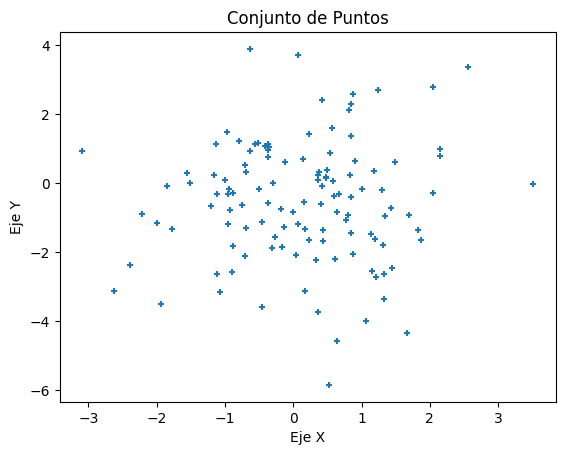

In [73]:
import matplotlib.pyplot as plt


# Dibujamos los puntos
plt.scatter(colors.T[0], colors.T[1], s=20, marker='+')
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.title('Conjunto de Puntos')

# Añadimos índices a cada punto
for i, (xi, yi) in enumerate(colors):
    plt.annotate(str(i), (xi, yi), textcoords="offset points", xytext=(0,10), ha='center', fontsize=6)

plt.show()
